In [1]:
%load_ext autoreload
%autoreload 2

import json
import os
import warnings

import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import Image, display
from jax import lax, random
from matplotlib import rcParams  # type: ignore

from jaxcmr import repetition
from jaxcmr.fitting import ScipyDE as fitting_method
from jaxcmr.helpers import (
    find_project_root,
    generate_trial_mask,
    import_from_string,
    load_data,
    save_dict_to_hdf5,
)
from jaxcmr.math import cosine_similarity_matrix, lb, power_scale
from jaxcmr.simulation import (
    simulate_h5_from_h5,
)
from jaxcmr.simulation import (
    simulate_study_free_recall_and_forced_stop as simulate_trial_fn,
)
from jaxcmr.summarize import summarize_parameters
from jaxcmr.transform_likelihood import (
    ExcludeTerminationLikelihoodFnGenerator as loss_fn_generator,
)

warnings.filterwarnings("ignore")

## Setup

In [2]:
# Dara parameters
base_data_tag = "HealeyKahana2014"
data_tag = "HealeyKahana2014"
data_path = "data/HealeyKahana2014.h5"
embedding_path = "data/peers-all-mpnet-base-v2.npy"
trial_query = "data['listtype'] == -1"

# Run configuration
run_tag = "fixed_term_best_of_3"
seed = 0
target_dir = "projects/HealeyKahana2014/"
experiment_count = 50

# Flow toggles
allow_repeated_recalls = False
filter_repeated_recalls = True
handle_elis = False
redo_fits = True
redo_sims = True
redo_figures = True

# Model configuration
model_name = "WeirdSemanticCMRNoStop"
model_factory_path = "jaxcmr.models.weird_semantic_cmr_no_stop.BaseCMRFactory"

# fitting hyperparameters
relative_tolerance = 0.001
popsize = 15
num_steps = 1000
cross_rate = 0.9
diff_w = 0.85
best_of = 3

# parameter bounds
parameters = {
    "fixed": {
    },
    "free": {
        "encoding_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "start_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "recall_drift_rate": [2.220446049250313e-16, 0.9999999999999998],
        "shared_support": [2.220446049250313e-16, 99.9999999999999998],
        "item_support": [2.220446049250313e-16, 99.9999999999999998],
        "learning_rate": [2.220446049250313e-16, 0.9999999999999998],
        "primacy_scale": [2.220446049250313e-16, 99.9999999999999998],
        "primacy_decay": [2.220446049250313e-16, 99.9999999999999998],
        "choice_sensitivity": [2.220446049250313e-16, 99.9999999999999998],
        "semantic_scale": [2.220446049250313e-16, 49.9999999999999998],
    },
}

comparison_analysis_paths = [
    "jaxcmr.analyses.distcrp.plot_dist_crp",
    "jaxcmr.analyses.nth_item_recall.plot_conditional_nth_item_recall_curve",
    "jaxcmr.analyses.termination_position.plot_termination_position_curve",
    "jaxcmr.analyses.nth_item_recall.plot_simple_nth_item_recall_curve",
    "jaxcmr.analyses.spc.plot_spc",
    "jaxcmr.analyses.crp.plot_crp",
    "jaxcmr.analyses.pnr.plot_pnr",
]


In [3]:
# add subdirectories for each product type: json, figures, h5
product_dirs = {}
for product in ["fits", "figures", "simulations"]:
    product_dir = os.path.join(target_dir, product)
    product_dirs[product] = product_dir
    if not os.path.exists(product_dir):
        os.makedirs(product_dir)

data = load_data(os.path.join(find_project_root(), data_path))
trial_mask = generate_trial_mask(data, trial_query)

max_size = np.max(data["pres_itemnos"])
embeddings = embeddings = np.load(
    os.path.join(find_project_root(), embedding_path)
).astype(np.float32)
connections = cosine_similarity_matrix(embeddings)
distances = 1 - connections

comparison_analyses = [import_from_string(path) for path in comparison_analysis_paths]
model_factory = import_from_string(model_factory_path)
BaseCMR = import_from_string(model_factory_path[:model_factory_path.rfind(".")]+".BaseCMR")


# derive list of query parameters from keys of `parameters`
parameters["fixed"]["allow_repeated_recalls"] = allow_repeated_recalls
query_parameters = list(parameters["free"].keys())

# make sure repeatedrecalls is in either both data_tag or data_path, or is in neither
if "repeatedrecalls" in data_tag.lower() or "repeatedrecalls" in data_path.lower():
    if (
        "repeatedrecalls" not in data_tag.lower()
        and "repeatedrecalls" not in data_path.lower()
    ):
        raise ValueError(
            "If 'repeatedrecalls' is in data_tag or data_path, it must be in both."
        )

## Fitting

In [4]:
fit_path = os.path.join(product_dirs["fits"], f"{data_tag}_{model_name}_{run_tag}.json")
print(fit_path)

if os.path.exists(fit_path) and not redo_fits:
    with open(fit_path) as f:
        results = json.load(f)
        if "subject" not in results["fits"]:
            results["fits"]["subject"] = results["subject"]

else:
    base_params = parameters["fixed"]
    bounds = parameters["free"]
    fitter = fitting_method(
        data,
        connections,
        base_params,
        model_factory,
        loss_fn_generator,
        hyperparams={
            "num_steps": num_steps,
            "pop_size": popsize,
            "relative_tolerance": relative_tolerance,
            "cross_over_rate": cross_rate,
            "diff_w": diff_w,
            "progress_bar": True,
            "display_iterations": False,
            "bounds": bounds,
            "best_of": best_of,
        },
    )

    results = fitter.fit(trial_mask)
    results = dict(results)

    with open(fit_path, "w") as f:
        json.dump(results, f, indent=4)

results["data_query"] = trial_query
results["model"] = model_name
results["name"] = f"{data_tag}_{model_name}_{run_tag}"

with open(fit_path, "w") as f:
    json.dump(results, f, indent=4)

print(
    summarize_parameters([results], query_parameters, include_std=True, include_ci=True)
)

projects/HealeyKahana2014/fits/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3.json


Subject=244, Fitness=552.4754028320312: 100%|██████████| 126/126 [22:10<00:00, 10.56s/it] 

| Parameter | Statistic | HealeyKahana2014 WeirdSemanticCMRNoStop fixed term best of 3 |
|---|---|---|
| fitness | mean | 509.02 +/- 15.97 |
|  | std | 90.23 |
|  | min | 249.53 |
|  | max | 704.28 |
| encoding drift rate | mean | 0.75 +/- 0.03 |
|  | std | 0.15 |
|  | min | 0.08 |
|  | max | 0.99 |
| start drift rate | mean | 0.19 +/- 0.04 |
|  | std | 0.20 |
|  | min | 0.00 |
|  | max | 0.77 |
| recall drift rate | mean | 0.83 +/- 0.03 |
|  | std | 0.14 |
|  | min | 0.04 |
|  | max | 1.00 |
| shared support | mean | 24.93 +/- 4.63 |
|  | std | 26.15 |
|  | min | 0.00 |
|  | max | 93.75 |
| item support | mean | 34.65 +/- 5.43 |
|  | std | 30.65 |
|  | min | 0.11 |
|  | max | 99.48 |
| learning rate | mean | 0.31 +/- 0.05 |
|  | std | 0.26 |
|  | min | 0.01 |
|  | max | 1.00 |
| primacy scale | mean | 22.75 +/- 5.02 |
|  | std | 28.34 |
|  | min | 0.00 |
|  | max | 99.50 |
| primacy decay | mean | 12.85 +/- 4.23 |
|  | std | 23.87 |
|  | min | 0.00 |
|  | max | 98.08 |
| choice sensit

## Simulation

In [5]:
sim_path = os.path.join(
    product_dirs["simulations"], f"{data_tag}_{model_name}_{run_tag}.h5"
)
print(sim_path)

with open(fit_path) as f:
    results = json.load(f)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results["subject"]


rng = random.PRNGKey(seed)
rng, rng_iter = random.split(rng)
trial_mask = generate_trial_mask(data, trial_query)
params = {key: jnp.array(val) for key, val in results["fits"].items()}  # type: ignore

if os.path.exists(sim_path) and not redo_sims:
    sim = load_data(sim_path)
    print(f"Loaded from {sim_path}")

else:
    sim = simulate_h5_from_h5(
        model_factory=model_factory,
        dataset=data,
        connections=connections,
        parameters=params,
        trial_mask=trial_mask,
        experiment_count=experiment_count,
        rng=rng_iter,
        simulate_trial_fn=simulate_trial_fn,
    )

    save_dict_to_hdf5(sim, sim_path) # type: ignore
    print(f"Saved to {sim_path}")

if filter_repeated_recalls:
    sim["recalls"] = repetition.filter_repeated_recalls(sim["recalls"])

params

projects/HealeyKahana2014/simulations/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3.h5
Saved to projects/HealeyKahana2014/simulations/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3.h5


{'encoding_drift_rate': Array([0.89351857, 0.76271755, 0.26902902, 0.8309604 , 0.71396625,
        0.7094643 , 0.9421855 , 0.52398616, 0.8455011 , 0.5115692 ,
        0.793006  , 0.62590957, 0.9078934 , 0.7149081 , 0.56094426,
        0.6288553 , 0.77792287, 0.9388844 , 0.7722126 , 0.6804966 ,
        0.77723765, 0.8455338 , 0.93954015, 0.6990514 , 0.75540715,
        0.56970495, 0.5452408 , 0.8007011 , 0.8729631 , 0.75965065,
        0.64189124, 0.83696544, 0.7650183 , 0.6464208 , 0.8751715 ,
        0.78748035, 0.7355068 , 0.6490655 , 0.6478664 , 0.779863  ,
        0.8526547 , 0.8111014 , 0.6947701 , 0.79369473, 0.86993396,
        0.24238053, 0.79222685, 0.96051234, 0.7079924 , 0.7044744 ,
        0.60220134, 0.84997284, 0.8329819 , 0.7072228 , 0.66833943,
        0.8743666 , 0.41059905, 0.43638173, 0.8205749 , 0.75748324,
        0.7510971 , 0.7031687 , 0.909612  , 0.57563114, 0.7609477 ,
        0.8661462 , 0.46296242, 0.90594214, 0.63528764, 0.8233409 ,
        0.8696187 , 0.527

## Figures

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_dist_crp.png)


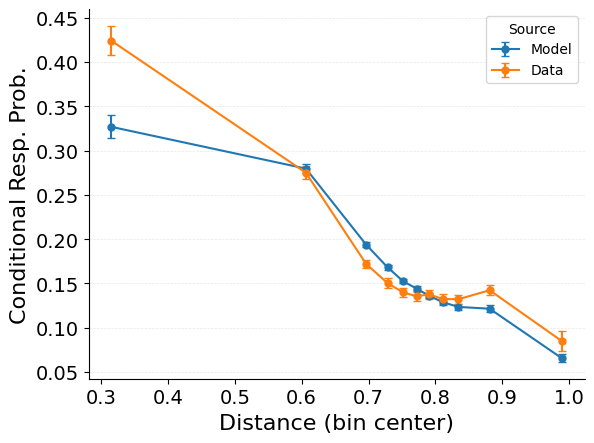

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_conditional_nth_item_recall_curve.png)


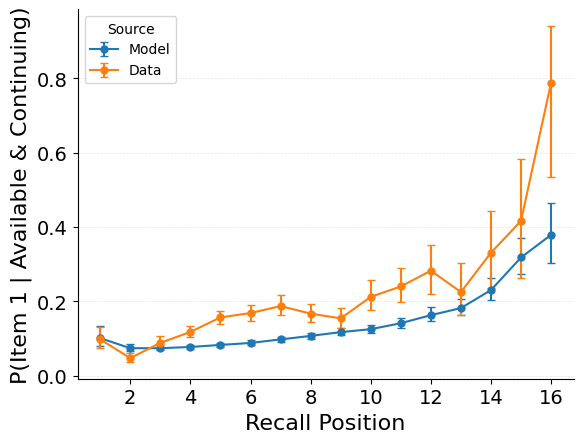

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_termination_position_curve.png)


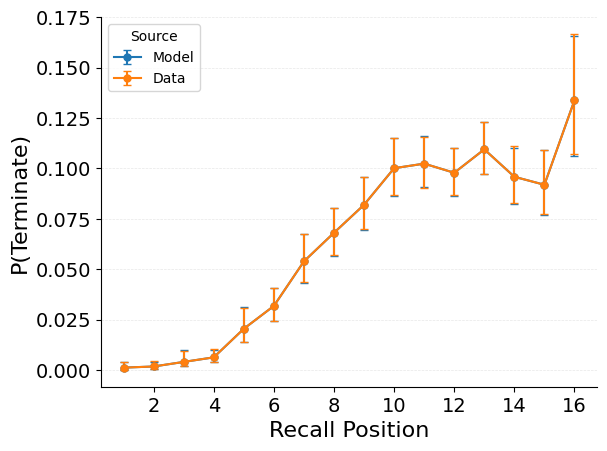

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_simple_nth_item_recall_curve.png)


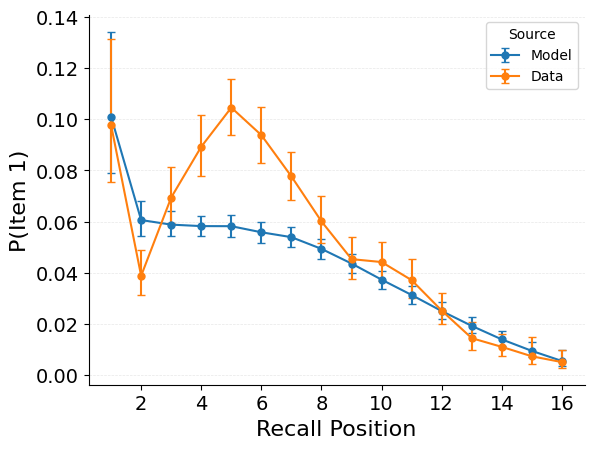

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_spc.png)


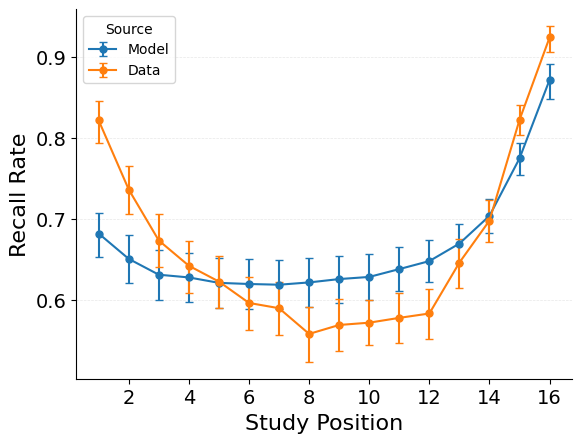

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_crp.png)


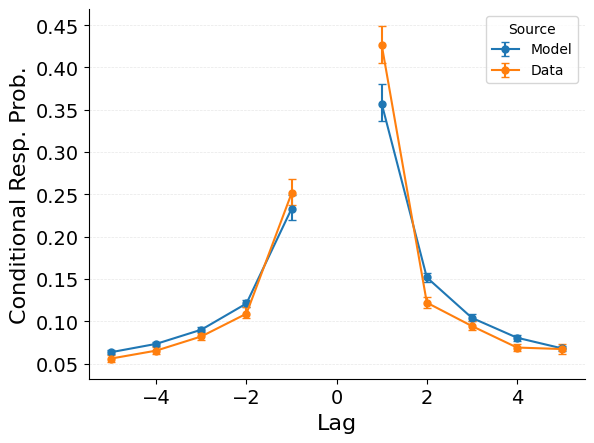

![](projects/HealeyKahana2014/figures/HealeyKahana2014_WeirdSemanticCMRNoStop_fixed_term_best_of_3_pnr.png)


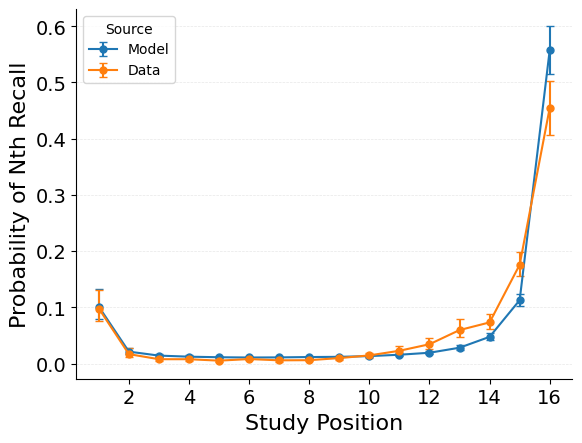

In [6]:
# | code-summary: mixed vs control views

for analysis in comparison_analyses:
    figure_str = f"{data_tag}_{model_name}_{run_tag}_{analysis.__name__[5:]}.png"
    figure_path = os.path.join(product_dirs["figures"], figure_str)
    print(f"![]({figure_path})")

    # if redo_figures, check if figure already exists and don't redo
    # we want to display the figure here if it already exists
    if os.path.exists(figure_path) and not redo_figures:
        display(Image(filename=figure_path))
        continue

    color_cycle = [each["color"] for each in rcParams["axes.prop_cycle"]]

    # Create a mask for data using np.isin for the selected list types
    trial_mask = generate_trial_mask(data, trial_query)
    sim_trial_mask = generate_trial_mask(sim, trial_query)

    axis = analysis(
        datasets=[sim, data],
        trial_masks=[np.array(sim_trial_mask), np.array(trial_mask)],
        color_cycle=color_cycle,
        labels=["Model", "Data"],
        contrast_name="Source",
        axis=None,
        distances=distances,
    )

    plt.savefig(figure_path, bbox_inches="tight", dpi=600)
    plt.show()

## Exploration

In [7]:
with open(fit_path) as f:
    results = json.load(f)
    if "subject" not in results["fits"]:
        results["fits"]["subject"] = results["subject"]

single_params = {key: val[0] for key, val in results["fits"].items()}  # type: ignore


model = model_factory(data, connections).create_model(single_params)
present = jnp.arange(1, 17)
model = lax.fori_loop(0, present.size, lambda i, m: m.experience(present[i]), model)
self = model.start_retrieving()
self = self.retrieve(2)
self.context.initial_state

self.outcome_probabilities()

Array([0.        , 0.70596945, 0.        , 0.1100632 , 0.01572225,
       0.00947877, 0.01524327, 0.00803186, 0.00283976, 0.00346841,
       0.01203799, 0.01901829, 0.01255335, 0.02063898, 0.04183294,
       0.01611163, 0.00698991], dtype=float32)

In [8]:
base_support = self.mcf.probe(self.context.state) * self.recallable

In [9]:
lax.cond(
            self.recall_total == 0,
            lambda: jnp.zeros_like(base_support),
            lambda: self.msem[self.recalls[self.recall_total - 1] - 1],
        )

Array([11.7047   ,  0.       ,  5.5726223,  3.8625908,  4.0259233,
        5.7649703,  4.514776 ,  2.2195055,  2.7303615,  5.662111 ,
        6.755583 ,  5.7400494,  6.8779235,  8.476149 ,  5.8918505,
        3.3224485], dtype=float32)

In [10]:
self.semantic_scale

Array(20.272818, dtype=float32, weak_type=True)